# Laboratorio 8: DuckDB

## Ejercicio 4. Analisis exploratorio con DuckDB

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

CC3084 Data Science, Semestre II 2026 | 2026-10-06

**Pregunta:** como se comportan los viajes de taxi de enero a agosto de 2026 en el tiempo, en sus caracteristicas, por tipo de taxi y por forma de pago, y que valores atipicos o inconsistentes aparecen?

**Datos.** Los 16 archivos de 2026 que descarga el cuaderno 01, consultados a traves de la vista `viajes_validos` de `sql/00_vistas.sql`. La vista lee los Parquet en cada consulta (no hay ninguna tabla) y aplica solo las dos exclusiones generales que decidio el cuaderno 02: montos negativos y viajes fuera del mes de su archivo. Los demas problemas de calidad se filtran en cada consulta que los necesita, con la columna `medible`.

**Consultas (4.2 y 4.3).** Cada una vive en `sql/03_*.sql` y esta documentada en `docs/consultas.md`. El cuaderno imprime el SQL antes de cada resultado.

## Preguntas de analisis (4.1)

Cada pregunta sale de algo que el conjunto de datos permite medir o de algo que ya aparecio en los cuadernos 01 y 02.

| # | Pregunta | Por que esta pregunta |
|---|---|---|
| P1 | Como cambia la cantidad de viajes por dia de enero a agosto, y se mueve igual en amarillos y verdes? | Los datos llegan por mes y el cuaderno 01 mostro a agosto como el mes mas flojo aun contando por dia |
| P2 | En que horas y dias de la semana se concentran los viajes de cada tipo? | Cada viaje trae su hora de salida al segundo, en hora local |
| P3 | Que distancia, duracion y velocidad tiene un viaje tipico, y como cambia la velocidad a lo largo del dia? | Hay distancia del taximetro y hora de salida y llegada; el cuaderno 02 dejo definido que viajes sirven para medirlas |
| P4 | Donde empiezan los viajes de cada tipo de taxi? | El perfil del cuaderno 02 dio mediana de recargo de congestion de 2.50 dolares en amarillos y 0 en verdes, una pista de que operan en zonas distintas |
| P5 | Como pagan los pasajeros de cada tipo y cuanta propina dejan? | Hay codigo de forma de pago y monto de propina, y el diccionario aclara que solo se registran las propinas con tarjeta |
| P6 | Como se distribuye el total pagado y de que se compone? | El total se desglosa en nueve componentes y tiene una cola larga (maximo de 7,053 dolares) |
| P7 | Que viajes son atipicos y que registros se contradicen entre columnas? | El cuaderno 02 encontro rangos imposibles columna por columna; falta revisar reglas que cruzan columnas |

## Mapa del notebook

1. Imports y configuracion
2. Obtencion de datos: correr las consultas de `sql/03_*.sql`
3. Preparacion de datos: tablas para graficar
4. Variables: las que agrega la vista y las consultas
5. Metricas: medianas, percentiles, porcentajes y un indice con base enero
6. Graficas: una por pregunta
7. Ejecucion: P1 (7.1), P2 (7.2), P3 (7.3 y 7.4), P4 (7.5 y 7.6), P5 (7.7 y 7.8), P6 (7.9 y 7.10), P7 (7.11 a 7.13) y bitacora (7.14)
8. Conclusiones: respuestas (4.4) y hallazgos (4.5)

## 1. Imports y configuracion

Las rutas salen de `scripts/consultas.py`. La conexion se abre con las vistas de `sql/00_vistas.sql`. Los colores de los dos tipos de taxi son los de todo el laboratorio; las formas de pago usan la paleta de roles del curso.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

RAIZ_LAB = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ_LAB / "scripts"))
import consultas

SEED = 42  # este cuaderno no muestrea; se deja por convencion del laboratorio
RAIZ = consultas.RAIZ
DIR_FIGURAS = RAIZ / "data" / "processed" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

TIPOS = ("yellow", "green")
COLOR_TAXI = {"yellow": "#e0a100", "green": "#2e8b57"}
COLOR_PAGO = {"tarjeta": "#0E4D45", "efectivo": "#B07D2B", "flex fare": "#3A7CA5", "otro": "#C9CFCB"}
DIAS_ES = {1: "Lun", 2: "Mar", 3: "Mie", 4: "Jue", 5: "Vie", 6: "Sab", 7: "Dom"}
MESES_ES = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
            7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}
BITACORA = []

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
})
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

## 2. Obtencion de datos

Una sola funcion: imprime la consulta de `sql/`, la ejecuta sobre la vista `viajes_validos` (es decir, sobre los Parquet) y anota el tiempo en la bitacora.

In [2]:
def correr(con, nombre, mostrar=True):
    """Imprime una consulta de sql/, la ejecuta y la anota en la bitacora."""
    if mostrar:
        print(consultas.leer_sql(nombre))
    resultado, segundos = consultas.correr_medido(con, nombre)
    BITACORA.append({"consulta": nombre, "filas_resultado": len(resultado), "segundos": round(segundos, 3)})
    return resultado

## 3. Preparacion de datos

Las consultas ya devuelven datos agregados (a lo sumo unos cientos de filas), asi que pandas solo los reacomoda para graficar: matrices dia por hora, porcentajes por forma de pago en columnas y un resumen de dias habiles contra fin de semana. Ningun calculo sobre los 30 millones de viajes se hace en pandas.

In [3]:
def matriz_hora_dia(hora_dia, tipo):
    """Viajes promedio por hora, con los dias de la semana como filas y las horas como columnas."""
    datos = hora_dia[hora_dia["tipo"] == tipo]
    return datos.pivot(index="dia_semana", columns="hora", values="viajes_por_hora")


def resumen_semana(hora_dia):
    """Viajes promedio por dia en dias habiles y en fin de semana, por tipo de taxi."""
    por_dia = hora_dia.groupby(["tipo", "dia_semana"])["viajes_por_hora"].sum().reset_index(name="viajes_por_dia")
    por_dia["parte"] = np.where(por_dia["dia_semana"] >= 6, "fin de semana", "lunes a viernes")
    tabla = por_dia.groupby(["tipo", "parte"])["viajes_por_dia"].mean().unstack()
    tabla["fin_de_semana_vs_habil_pct"] = 100 * (tabla["fin de semana"] / tabla["lunes a viernes"] - 1)
    return tabla.loc[list(TIPOS)]


def pago_ancho(pago_por_mes, tipo):
    """Porcentaje de viajes de cada forma de pago por mes, con las formas de pago como columnas."""
    datos = pago_por_mes[pago_por_mes["tipo"] == tipo]
    tabla = datos.pivot(index="mes", columns="pago", values="pct_del_mes").fillna(0)
    return tabla[[p for p in COLOR_PAGO if p in tabla.columns]]

## 4. Variables

Las variables derivadas se construyen en SQL, no en pandas, para que DuckDB las calcule mientras lee los Parquet. La vista `viajes_validos` agrega `mes`, `hora` y `dia_semana` (1 lunes a 7 domingo) a partir de la hora de salida, `duracion_min` (llegada menos salida, en minutos) y `medible`, que marca los viajes que sirven para duracion, distancia y velocidad. Las consultas agregan la velocidad (`trip_distance / (duracion_min / 60)`, en millas por hora), la forma de pago agrupada (tarjeta, efectivo, Flex Fare y otro), la propina como porcentaje de la tarifa y la suma de los componentes del total.

## 5. Metricas

No hay modelo: es un analisis descriptivo. Se eligen metricas que no se rompan con los valores extremos que encontro el cuaderno 02.

- **Medianas y percentiles** en vez de promedios para distancia, duracion, velocidad y montos, porque una sola distancia de 328,522 millas mueve un promedio pero no una mediana.
- **Porcentaje dentro de cada tipo** para comparar amarillos con verdes, porque los amarillos tienen 88 veces mas viajes.
- **Viajes por dia** para comparar meses de 28, 30 y 31 dias, y un **indice con base enero = 100** para ver si los dos tipos se mueven igual aunque sus volumenes sean tan distintos.
- **Limite de Tukey** (tercer cuartil mas 1.5 veces el rango intercuartil) como referencia comun de atipico, para despues revisar si lo que marca son errores.

In [4]:
def indice_base(valores, base):
    """Valores expresados como indice, con la base igual a 100."""
    return 100 * valores / base


def indice_mensual(por_mes):
    """Viajes por dia de cada mes como indice con enero = 100, por tipo de taxi."""
    tabla = por_mes.copy()
    enero = tabla[tabla["mes"] == 1].set_index("tipo")["viajes_por_dia"]
    tabla["indice_enero_100"] = indice_base(tabla["viajes_por_dia"], tabla["tipo"].map(enero))
    return tabla

## 6. Graficas

Una grafica por pregunta. Las que comparan amarillos con verdes usan porcentajes o indices, o van en paneles separados con su propia escala, porque en un eje comun los verdes quedarian aplastados contra cero.

In [5]:
ROLE = {"actual": "#0E4D45", "model": "#3A7CA5", "compare": "#B07D2B",
        "up": "#3F8A26", "down": "#A4493D", "missing": "#C9CFCB", "shade": "#EEF0EE"}
MILES = FuncFormatter(lambda v, _: f"{v:,.0f}")


def style_ax(ax, title, xlabel, ylabel, subtitle=None, grid_axis="y"):
    """Titulo, ejes y bordes limpios con el estilo del laboratorio."""
    ax.set_title(title + (f"\n{subtitle}" if subtitle else ""), fontsize=16, fontweight="bold", pad=18)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", labelpad=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=12)
    ax.grid(axis=grid_axis, alpha=0.3)


def guardar(fig, nombre):
    """Ajusta los margenes y guarda la figura en la carpeta de figuras."""
    fig.tight_layout()
    fig.savefig(DIR_FIGURAS / nombre, bbox_inches="tight")


def etiquetar_pares(ax, tabla, x, y, fmt, etiqueta=None, cada=1, separacion=0.03):
    """Etiqueta dos series de lineas: la mas alta encima de su punto y la mas baja debajo."""
    etiqueta = etiqueta or y
    valores = tabla.pivot(index=x, columns="tipo", values=y)
    textos = tabla.pivot(index=x, columns="tipo", values=etiqueta)
    rango = (valores.max().max() - valores.min().min()) or 1
    for i, xi in enumerate(valores.index):
        if i % cada:
            continue
        for tipo in TIPOS:
            otro = [t for t in TIPOS if t != tipo][0]
            mio, del_otro = valores.loc[xi, tipo], valores.loc[xi, otro]
            arriba = mio > del_otro or (mio == del_otro and tipo == TIPOS[0])
            ax.text(xi, valores.loc[xi, tipo] + rango * separacion * (1 if arriba else -1),
                    fmt.format(textos.loc[xi, tipo]), ha="center", va="bottom" if arriba else "top",
                    fontsize=10, fontweight="bold", color=COLOR_TAXI[tipo])


def graficar_indice_mensual(tabla):
    """Lineas del indice de viajes por dia (enero = 100) de cada tipo, con los viajes por dia anotados."""
    if tabla.empty:
        print("No hay datos mensuales para graficar.")
        return None, None
    fig, ax = plt.subplots(figsize=(16, 9))
    for tipo in TIPOS:
        datos = tabla[tabla["tipo"] == tipo]
        ax.plot(datos["mes"], datos["indice_enero_100"], color=COLOR_TAXI[tipo], linewidth=2.5, marker="o",
                markersize=7, markeredgecolor="white", label=f"taxis {tipo}")
    etiquetar_pares(ax, tabla, "mes", "indice_enero_100", "{:,.0f}/dia", etiqueta="viajes_por_dia")
    ax.axhline(100, color="#444444", linestyle="--", linewidth=0.8, label="Enero = 100")
    ax.set_xticks(range(1, 9), [MESES_ES[m] for m in range(1, 9)])
    ax.set_ylim(tabla["indice_enero_100"].min() - 6, tabla["indice_enero_100"].max() + 6)
    style_ax(ax, "Viajes por dia, indice con enero = 100", "Mes de 2026", "Indice (enero = 100)",
             subtitle="Etiquetas: viajes promedio por dia de cada mes")
    ax.legend(loc="upper left")
    guardar(fig, "03_viajes_por_mes.png")
    return fig, ax


def graficar_hora_dia(hora_dia):
    """Mapas de calor de viajes promedio por hora y dia de la semana, un panel por tipo."""
    if hora_dia.empty:
        print("No hay datos por hora para graficar.")
        return None, None
    fig, axes = plt.subplots(2, 1, figsize=(16, 11))
    for ax, tipo, cmap in zip(axes, TIPOS, ["YlOrBr", "Greens"]):
        matriz = matriz_hora_dia(hora_dia, tipo)
        imagen = ax.imshow(matriz.values, aspect="auto", cmap=cmap)
        fila, col = np.unravel_index(np.nanargmax(matriz.values), matriz.shape)
        ax.text(col, fila, f"{matriz.values[fila, col]:,.0f}", ha="center", va="center", fontsize=10,
                fontweight="bold", color="white")
        ax.set_xticks(range(24), [f"{h}" for h in range(24)])
        ax.set_yticks(range(7), [DIAS_ES[d] for d in matriz.index])
        style_ax(ax, f"Viajes promedio por hora | taxis {tipo}", "Hora de salida", "",
                 subtitle="Enero a agosto de 2026; el numero marca la hora con mas viajes")
        ax.grid(False)
        barra = fig.colorbar(imagen, ax=ax, pad=0.01)
        barra.set_label("Viajes por hora", fontsize=12, fontweight="bold")
        barra.ax.yaxis.set_major_formatter(MILES)
    guardar(fig, "03_hora_dia.png")
    return fig, axes


def graficar_velocidad_hora(vel):
    """Velocidad y duracion medianas por hora de salida, un panel para cada una."""
    if vel.empty:
        print("No hay datos de velocidad para graficar.")
        return None, None
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    for ax, columna, etiqueta, fmt in [
        (axes[0], "velocidad_mediana_mph", "Velocidad mediana (mph)", "{:.1f}"),
        (axes[1], "duracion_mediana_min", "Duracion mediana (min)", "{:.1f}"),
    ]:
        for tipo in TIPOS:
            datos = vel[vel["tipo"] == tipo]
            ax.plot(datos["hora"], datos[columna], color=COLOR_TAXI[tipo], linewidth=2.5, marker="o", markersize=6,
                    markeredgecolor="white", label=f"taxis {tipo}")
        etiquetar_pares(ax, vel, "hora", columna, fmt, cada=3, separacion=0.04)
        ax.set_ylim(0, vel[columna].max() * 1.2)
        style_ax(ax, etiqueta + " segun la hora de salida", "", etiqueta,
                 subtitle="Solo viajes medibles, enero a agosto de 2026")
        ax.legend(loc="upper right")
    axes[-1].set_xticks(range(24))
    axes[-1].set_xlabel("Hora de salida", fontsize=13, fontweight="bold", labelpad=12)
    guardar(fig, "03_velocidad_por_hora.png")
    return fig, axes


def graficar_barrios(barrios):
    """Barras horizontales del porcentaje de viajes que empieza en cada barrio, por tipo."""
    if barrios.empty:
        print("No hay datos de barrios para graficar.")
        return None, None
    tabla = barrios.pivot(index="barrio", columns="tipo", values="pct_del_tipo").fillna(0)
    tabla = tabla.reindex(columns=list(TIPOS)).sort_values("yellow")
    fig, ax = plt.subplots(figsize=(16, 8))
    alto = 0.4
    y = np.arange(len(tabla))
    for i, tipo in enumerate(TIPOS):
        posiciones = y + (i - 0.5) * alto
        ax.barh(posiciones, tabla[tipo], height=alto, color=COLOR_TAXI[tipo], edgecolor="white", linewidth=0.5,
                label=f"taxis {tipo}")
        for p, v in zip(posiciones, tabla[tipo]):
            ax.text(v + 0.6, p, f"{v:.1f}%", va="center", fontsize=10, fontweight="bold", color=ROLE["actual"])
    ax.set_yticks(y, tabla.index)
    ax.set_xlim(0, 100)
    style_ax(ax, "Barrio donde empieza el viaje", "Viajes del tipo de taxi (%)", "",
             subtitle="Enero a agosto de 2026", grid_axis="x")
    ax.legend(loc="lower right")
    guardar(fig, "03_barrios.png")
    return fig, ax


def graficar_pago(pago_por_mes):
    """Barras apiladas al 100% de la forma de pago por mes, un panel por tipo."""
    if pago_por_mes.empty:
        print("No hay datos de pago para graficar.")
        return None, None
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    for ax, tipo in zip(axes, TIPOS):
        tabla = pago_ancho(pago_por_mes, tipo)
        abajo = np.zeros(len(tabla))
        x = np.arange(len(tabla))
        for pago in tabla.columns:
            ax.bar(x, tabla[pago], bottom=abajo, color=COLOR_PAGO[pago], edgecolor="white", linewidth=0.5, label=pago)
            for xi, b, v in zip(x, abajo, tabla[pago]):
                if v >= 4:
                    ax.text(xi, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=10, fontweight="bold",
                            color="white" if pago != "otro" else ROLE["actual"])
            abajo = abajo + tabla[pago].values
        ax.set_xticks(x, [MESES_ES[m] for m in tabla.index])
        ax.set_ylim(0, 100)
        style_ax(ax, f"Forma de pago por mes | taxis {tipo}", "Mes de 2026", "Viajes del mes (%)")
    axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.12), ncol=4)
    guardar(fig, "03_pago_por_mes.png")
    return fig, axes


def graficar_total(histograma, limites):
    """Distribucion del total pagado por viaje, en intervalos de 2 dolares, por tipo."""
    if histograma.empty:
        print("No hay datos del total para graficar.")
        return None, None
    fig, ax = plt.subplots(figsize=(16, 9))
    for tipo in TIPOS:
        datos = histograma[histograma["tipo"] == tipo]
        ax.step(datos["desde_dolares"], datos["pct_del_tipo"], where="post", color=COLOR_TAXI[tipo], linewidth=2.2,
                label=f"taxis {tipo}")
        limite = limites[(limites["tipo"] == tipo) & (limites["variable"] == "total_dolares")]["limite_superior"].iloc[0]
        ax.axvline(limite, color=COLOR_TAXI[tipo], linestyle="--", linewidth=1.5,
                   label=f"Limite de Tukey {tipo} ({limite:,.2f} dolares)")
    ax.annotate("Ultimo intervalo: 150 dolares o mas", xy=(150, 0.3), xytext=(118, 2.5), fontsize=11,
                arrowprops=dict(arrowstyle="-", color="#444444"))
    ax.set_xlim(0, 154)
    style_ax(ax, "Distribucion del total pagado por viaje", "Total del viaje (dolares, intervalos de 2)",
             "Viajes del tipo (%)", subtitle="Enero a agosto de 2026, viajes validos")
    ax.legend(loc="upper right")
    guardar(fig, "03_total.png")
    return fig, ax


def graficar_composicion(composicion):
    """Barras apiladas del total promedio desglosado en sus componentes, por tipo."""
    if composicion.empty:
        print("No hay datos de composicion para graficar.")
        return None, None
    componentes = ["tarifa", "propina", "recargo_congestion", "cargo_zona_central", "cargo_aeropuerto", "peajes",
                   "extras", "impuesto_y_mejora"]
    colores = ["#0E4D45", "#3F8A26", "#3A7CA5", "#7FB3D5", "#B07D2B", "#A4493D", "#C9CFCB", "#7F8F8B"]
    tabla = composicion.set_index("tipo").loc[list(TIPOS)]
    fig, ax = plt.subplots(figsize=(16, 6))
    izquierda = np.zeros(len(tabla))
    y = np.arange(len(tabla))
    for componente, color in zip(componentes, colores):
        valores = tabla[componente].values
        ax.barh(y, valores, left=izquierda, color=color, edgecolor="white", linewidth=0.5,
                label=componente.replace("_", " "))
        for yi, iz, v in zip(y, izquierda, valores):
            if v >= 1.4:
                ax.text(iz + v / 2, yi, f"{v:.2f}", ha="center", va="center", fontsize=10, fontweight="bold",
                        color="white")
        izquierda = izquierda + valores
    for yi, total in zip(y, tabla["total"]):
        ax.text(total + 0.3, yi, f"total {total:.2f}", va="center", fontsize=11, fontweight="bold",
                color=ROLE["actual"])
    ax.set_yticks(y, [f"taxis {t}" for t in tabla.index])
    ax.set_xlim(0, tabla["total"].max() * 1.15)
    style_ax(ax, "Total promedio por viaje y sus componentes", "Dolares por viaje", "",
             subtitle="Solo viajes cuyo total coincide con la suma de sus componentes", grid_axis="x")
    ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=4)
    guardar(fig, "03_composicion.png")
    return fig, ax

## 7. Ejecucion

Cada paso imprime la consulta y su resultado; despues va la interpretacion con los numeros obtenidos.

### 7.1 P1. Viajes por mes

-- 03_viajes_por_mes.sql
-- Objetivo: viajes por mes y por dia de cada tipo de taxi (pregunta 1). Se
-- divide entre los dias del mes porque febrero tiene 28 y los demas 30 o 31.
-- Fuente: vista viajes_validos (sql/00_vistas.sql) sobre data/raw.
select
    tipo,
    mes,
    count(*) as viajes,
    any_value(day(last_day(pickup_datetime))) as dias,
    count(*) / any_value(day(last_day(pickup_datetime))) as viajes_por_dia
from viajes_validos
group by tipo, mes
order by tipo desc, mes;



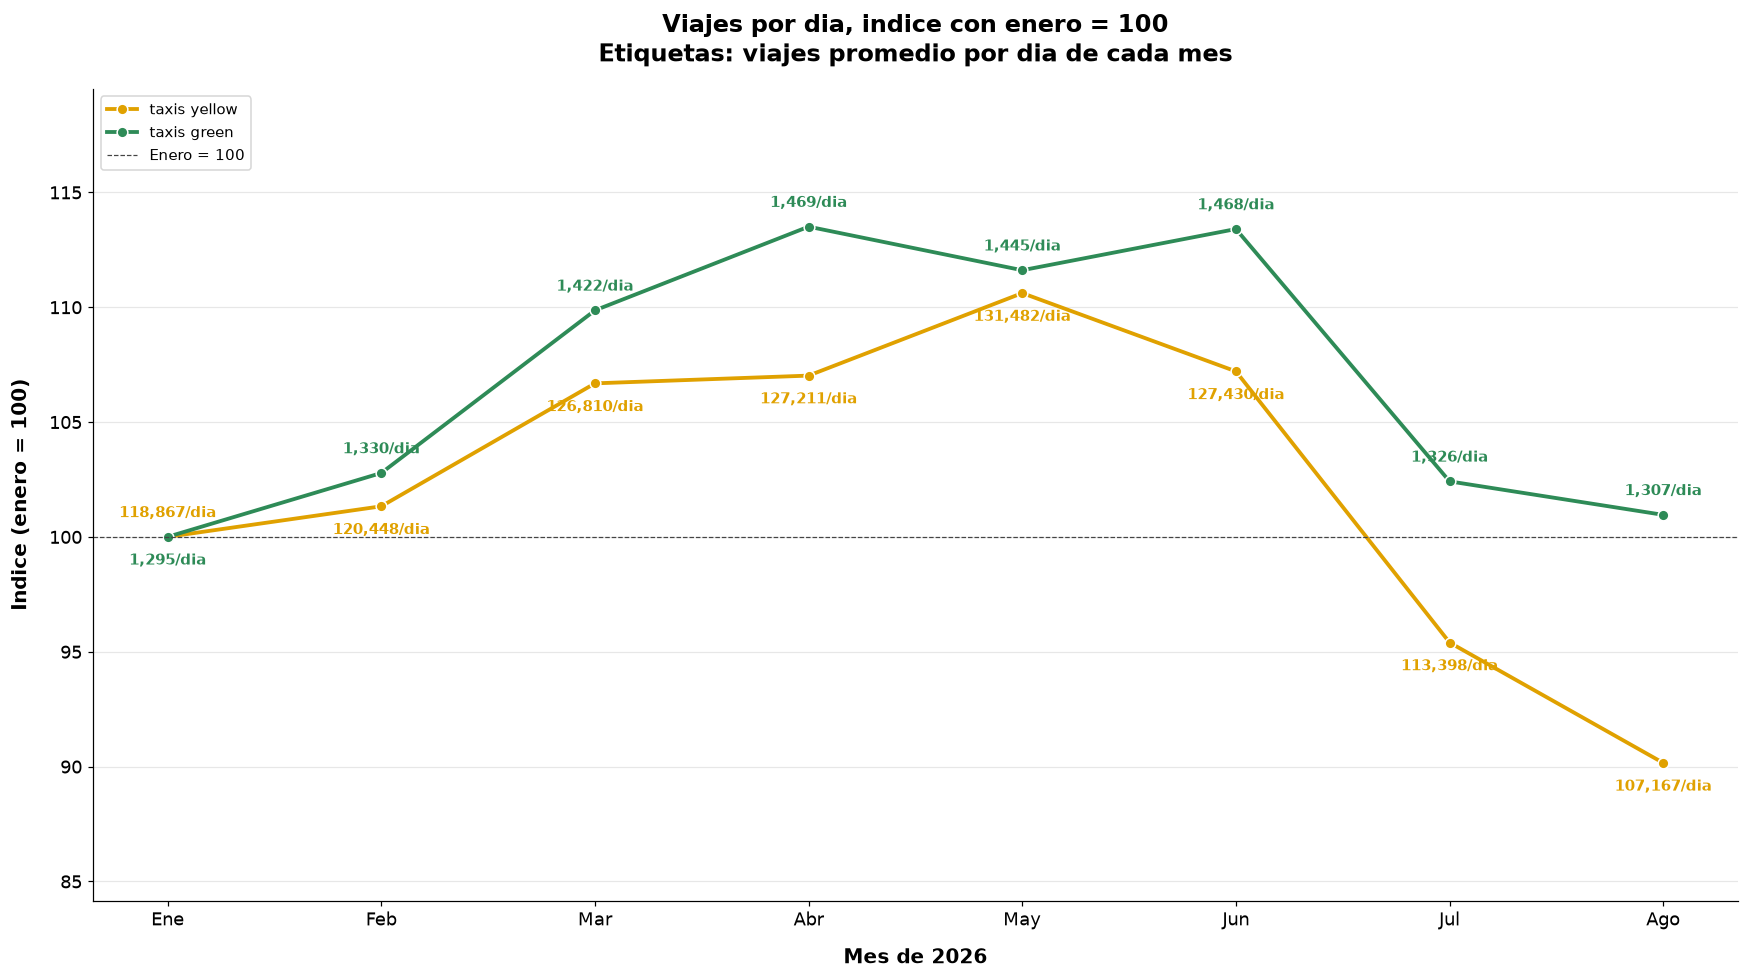

,tipo,mes,viajes,dias,viajes_por_dia,indice_enero_100
0,yellow,1,3684881,31,118867.1,100.0
1,yellow,2,3372546,28,120448.1,101.3
2,yellow,3,3931115,31,126810.2,106.7
3,yellow,4,3816343,30,127211.4,107.0
4,yellow,5,4075934,31,131481.7,110.6
5,yellow,6,3822900,30,127430.0,107.2
6,yellow,7,3515332,31,113397.8,95.4
7,yellow,8,3322191,31,107167.5,90.2
8,green,1,40130,31,1294.5,100.0
9,green,2,37254,28,1330.5,102.8


In [6]:
con = consultas.conectar()
por_mes = indice_mensual(correr(con, "03_viajes_por_mes.sql"))
fig, ax = graficar_indice_mensual(por_mes)
plt.show()
por_mes.round(1)

Los dos tipos suben de enero a la primavera y caen en verano, pero no con la misma fuerza. Los amarillos pasan de 118,867 viajes por dia en enero a un maximo de 131,482 en mayo (indice 110.6) y despues caen a 107,167 en agosto (indice 90.2): agosto queda 18.5% por debajo de mayo y casi 10% por debajo de enero. Los verdes suben antes y mas, hasta 1,469 por dia en abril y 1,468 en junio (indice 113.5 y 113.4), y en julio y agosto vuelven casi al nivel de enero (1,307 por dia, indice 101.0) sin caer por debajo de el. La caida de verano es sobre todo de los amarillos, que dependen de Manhattan (paso 7.5). Con ocho meses de un solo anio no se puede separar si es un efecto de temporada o una tendencia; comparar con el mismo periodo de 2024 (ejercicio 5) lo permite.

### 7.2 P2. Hora y dia de la semana

-- 03_hora_dia.sql
-- Objetivo: viajes promedio por hora en cada dia de la semana, por tipo de
-- taxi (pregunta 2). Se divide entre cuantas veces aparece cada dia de la
-- semana en el periodo, porque de enero a agosto de 2026 algunos dias se
-- repiten 35 veces y otros 34.
-- Fuente: vista viajes_validos sobre data/raw.
with conteo as (
    select tipo, dia_semana, hora, count(*) as viajes
    from viajes_validos
    group by tipo, dia_semana, hora
),
dias as (
    select tipo, dia_semana, count(distinct cast(pickup_datetime as date)) as dias
    from viajes_validos
    group by tipo, dia_semana
)
select
    conteo.tipo,
    conteo.dia_semana,
    conteo.hora,
    conteo.viajes,
    dias.dias,
    conteo.viajes / dias.dias as viajes_por_hora
from conteo
join dias using (tipo, dia_semana)
order by conteo.tipo desc, conteo.dia_semana, conteo.hora;



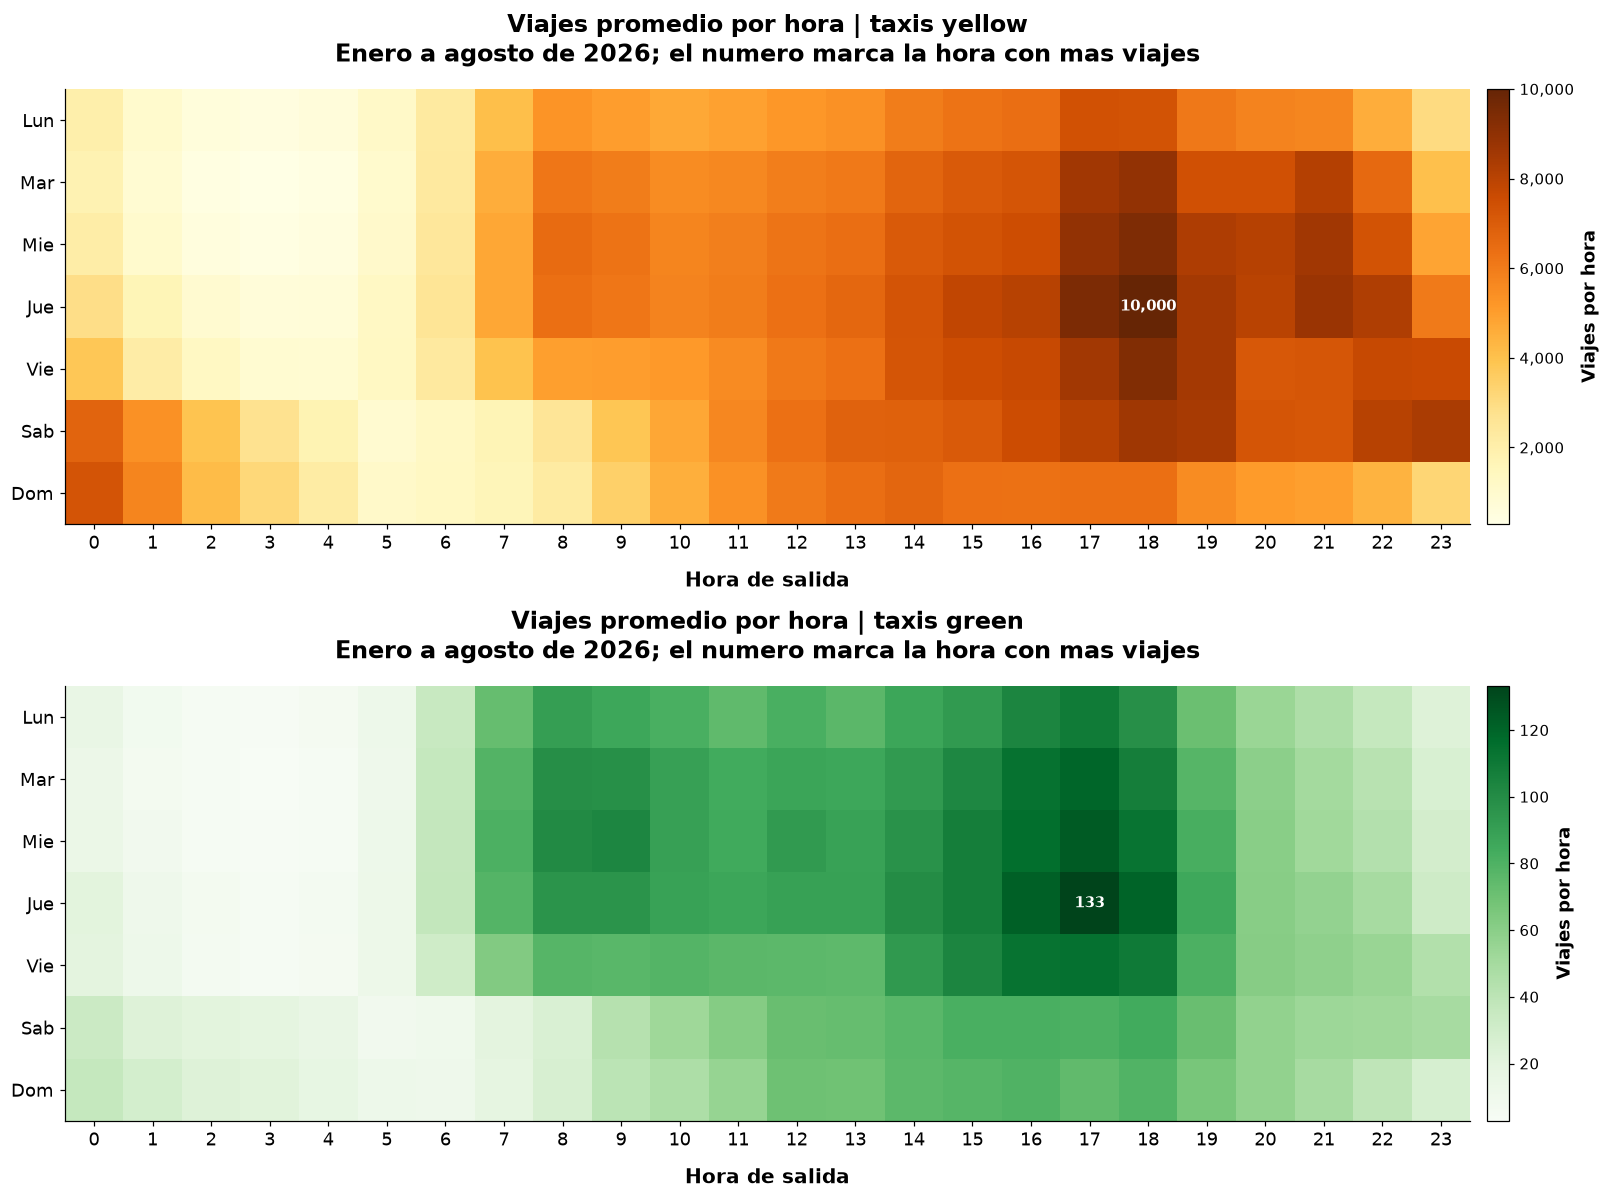

parte,fin de semana,lunes a viernes,fin_de_semana_vs_habil_pct
tipo,,,
yellow,120682.1,121939.5,-1.0
green,1129.5,1485.5,-24.0


In [7]:
hora_dia = correr(con, "03_hora_dia.sql")
fig, axes = graficar_hora_dia(hora_dia)
plt.show()
resumen_semana(hora_dia).round(1)

Los amarillos tienen su hora mas fuerte el jueves de 18:00 a 19:00, con 10,000 viajes por hora en promedio, y en dias habiles el bloque fuerte va de las 17:00 a las 21:00. La madrugada de lunes a viernes, de 2:00 a 5:00, casi no tiene viajes. El fin de semana cambia la forma pero no el volumen: el sabado y el domingo hay mucha actividad entre la medianoche y las 2:00 y poca en la manana, y al sumar las 24 horas un dia de fin de semana tiene solo 1.0% menos viajes que uno habil.

Los verdes siguen un patron de dias de trabajo. Su hora mas fuerte es el jueves a las 17:00 (133 viajes por hora), la manana de dias habiles (8:00 y 9:00) ya es intensa, la noche se apaga antes que en los amarillos, y un dia de fin de semana tiene 24% menos viajes que uno habil.

### 7.3 P3. Distancia, duracion y velocidad

In [8]:
correr(con, "03_caracteristicas.sql").round(2)

-- 03_caracteristicas.sql
-- Objetivo: distribucion de distancia, duracion y velocidad de los viajes de
-- cada tipo (pregunta 3), con percentiles exactos.
-- Fuente: vista viajes_validos, solo viajes medibles (sin proveedor 7, con
-- duracion entre 0 y 24 horas y distancia entre 0 y 100 millas).
with medibles as (
    select
        tipo,
        trip_distance as distancia_millas,
        duracion_min,
        trip_distance / (duracion_min / 60) as velocidad_mph
    from viajes_validos
    where medible
),
largo as (
    unpivot medibles
    on distancia_millas, duracion_min, velocidad_mph
    into name variable value valor
)
select
    variable,
    tipo,
    count(*) as viajes,
    quantile_cont(valor, 0.10) as p10,
    quantile_cont(valor, 0.25) as p25,
    quantile_cont(valor, 0.50) as mediana,
    quantile_cont(valor, 0.75) as p75,
    quantile_cont(valor, 0.90) as p90,
    quantile_cont(valor, 0.99) as p99
from largo
group by variable, tipo
order by variable, tipo desc;



,variable,tipo,viajes,p10,p25,mediana,p75,p90,p99
0,distancia_millas,yellow,28242681,0.69,1.10,1.93,3.95,8.70,19.56
1,distancia_millas,green,324158,0.86,1.33,2.15,3.78,7.53,17.80
2,duracion_min,yellow,28242681,5.38,8.62,14.12,22.27,33.48,71.68
3,duracion_min,green,324158,5.65,8.68,13.35,20.73,33.08,82.69
4,velocidad_mph,yellow,28242681,4.98,6.83,9.28,12.93,19.04,34.45
5,velocidad_mph,green,324158,6.22,7.93,10.04,13.12,18.40,34.28


Un viaje amarillo tipico (la mediana) recorre 1.93 millas en 14.1 minutos, a 9.3 millas por hora; uno verde, 2.15 millas en 13.4 minutos, a 10.0 mph. La mitad central de los viajes amarillos va de 1.1 a 4.0 millas y de 8.6 a 22.3 minutos. Las colas son largas: el 10% mas largo de los amarillos pasa de 8.7 millas, que es el rango de los viajes a los aeropuertos, y el 1% mas largo pasa de 19.6 millas y de 72 minutos. Por eso aqui se usan percentiles y no promedios. Son percentiles exactos (`quantile_cont`) sobre 28.2 millones de viajes medibles; los 1.3 millones restantes (proveedor 7, distancia cero o duraciones imposibles) no entran en este calculo.

### 7.4 P3. Velocidad segun la hora

-- 03_velocidad_por_hora.sql
-- Objetivo: velocidad, duracion y distancia medianas segun la hora de salida
-- (pregunta 3). La velocidad es la de todo el viaje: distancia del taximetro
-- entre el tiempo con el taximetro encendido.
-- Fuente: vista viajes_validos, solo viajes medibles.
select
    tipo,
    hora,
    count(*) as viajes,
    median(trip_distance / (duracion_min / 60)) as velocidad_mediana_mph,
    median(duracion_min) as duracion_mediana_min,
    median(trip_distance) as distancia_mediana_millas
from viajes_validos
where medible
group by tipo, hora
order by tipo desc, hora;



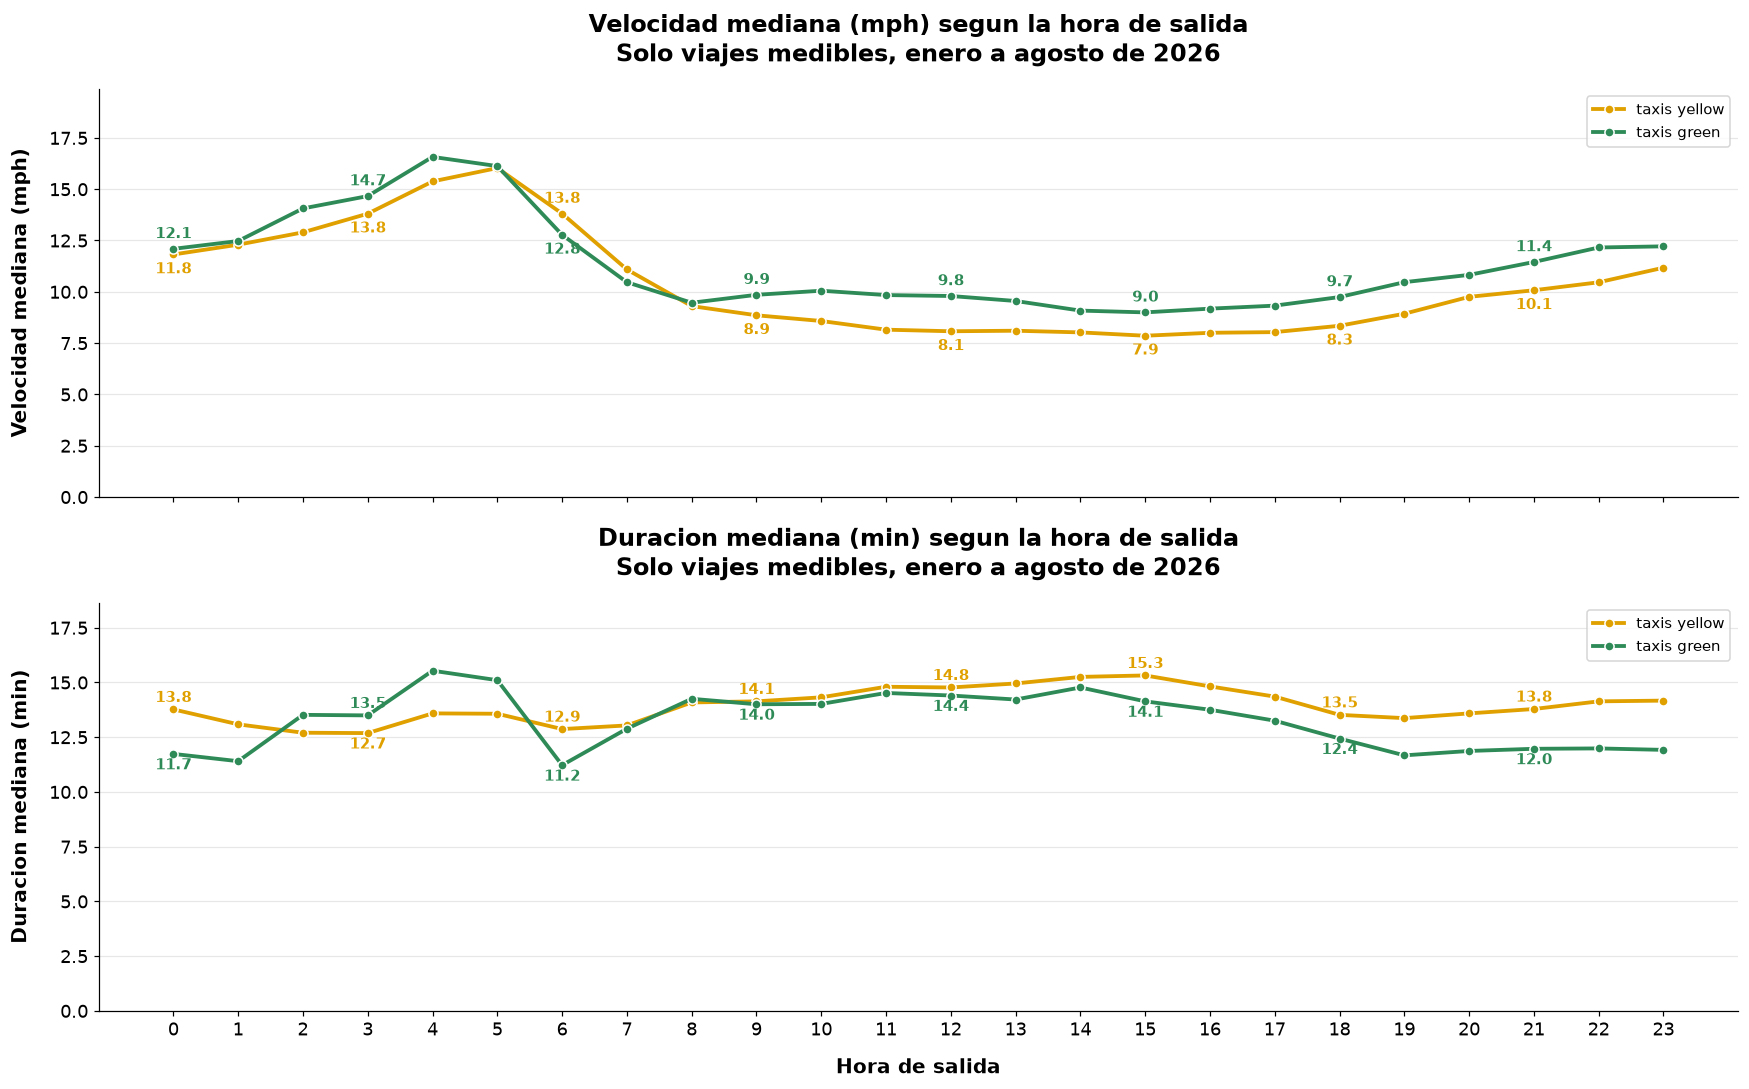

,tipo,hora,viajes,velocidad_mediana_mph,duracion_mediana_min,distancia_mediana_millas
5,yellow,5,261669,16.03,13.57,3.71
8,yellow,8,1151223,9.30,14.08,2.00
15,yellow,15,1670323,7.86,15.32,1.73
18,yellow,18,1833729,8.34,13.52,1.63
22,yellow,22,1593008,10.46,14.13,2.29
29,green,5,2466,16.12,15.10,4.60
32,green,8,17568,9.46,14.25,2.09
39,green,15,22659,8.99,14.13,2.05
42,green,18,23776,9.74,12.43,1.96
46,green,22,10425,12.16,11.98,2.30


In [9]:
velocidad = correr(con, "03_velocidad_por_hora.sql")
fig, axes = graficar_velocidad_hora(velocidad)
plt.show()
velocidad[velocidad["hora"].isin([5, 8, 15, 18, 22])].round(2)

La velocidad cambia mucho con la hora y la duracion casi nada. Los amarillos van a 16.0 mph a las 5:00 y a 7.9 mph a las 15:00, la mitad, pero la duracion mediana solo pasa de 13.6 a 15.3 minutos. Lo que se ajusta es la distancia: a las 5:00 el viaje mediano es de 3.71 millas y a las 15:00 de 1.73. Los viajes en taxi rondan los 13 a 15 minutos a cualquier hora, y cuando el trafico esta lento se recorre menos distancia en ese tiempo. Una explicacion posible es que en las horas lentas la gente toma taxi solo para trayectos cortos; los datos muestran el patron, pero no permiten confirmar la causa. Los verdes siguen la misma curva y durante el dia van un poco mas rapido (9.0 contra 7.9 mph a las 15:00), coherente con que circulan menos dentro de Manhattan.

### 7.5 P4. Barrio de origen

-- 03_barrios.sql
-- Objetivo: en que barrio empiezan los viajes de cada tipo de taxi (pregunta 4).
-- Fuente: vista viajes_validos unida con la vista zonas (taxi_zone_lookup.csv)
-- por PULocationID. Las zonas 264 y 265 aparecen como Unknown y N/A.
select
    v.tipo,
    coalesce(z.Borough, 'sin zona') as barrio,
    count(*) as viajes,
    100.0 * count(*) / sum(count(*)) over (partition by v.tipo) as pct_del_tipo
from viajes_validos v
left join zonas z on v.PULocationID = z.LocationID
group by v.tipo, barrio
order by v.tipo desc, viajes desc;



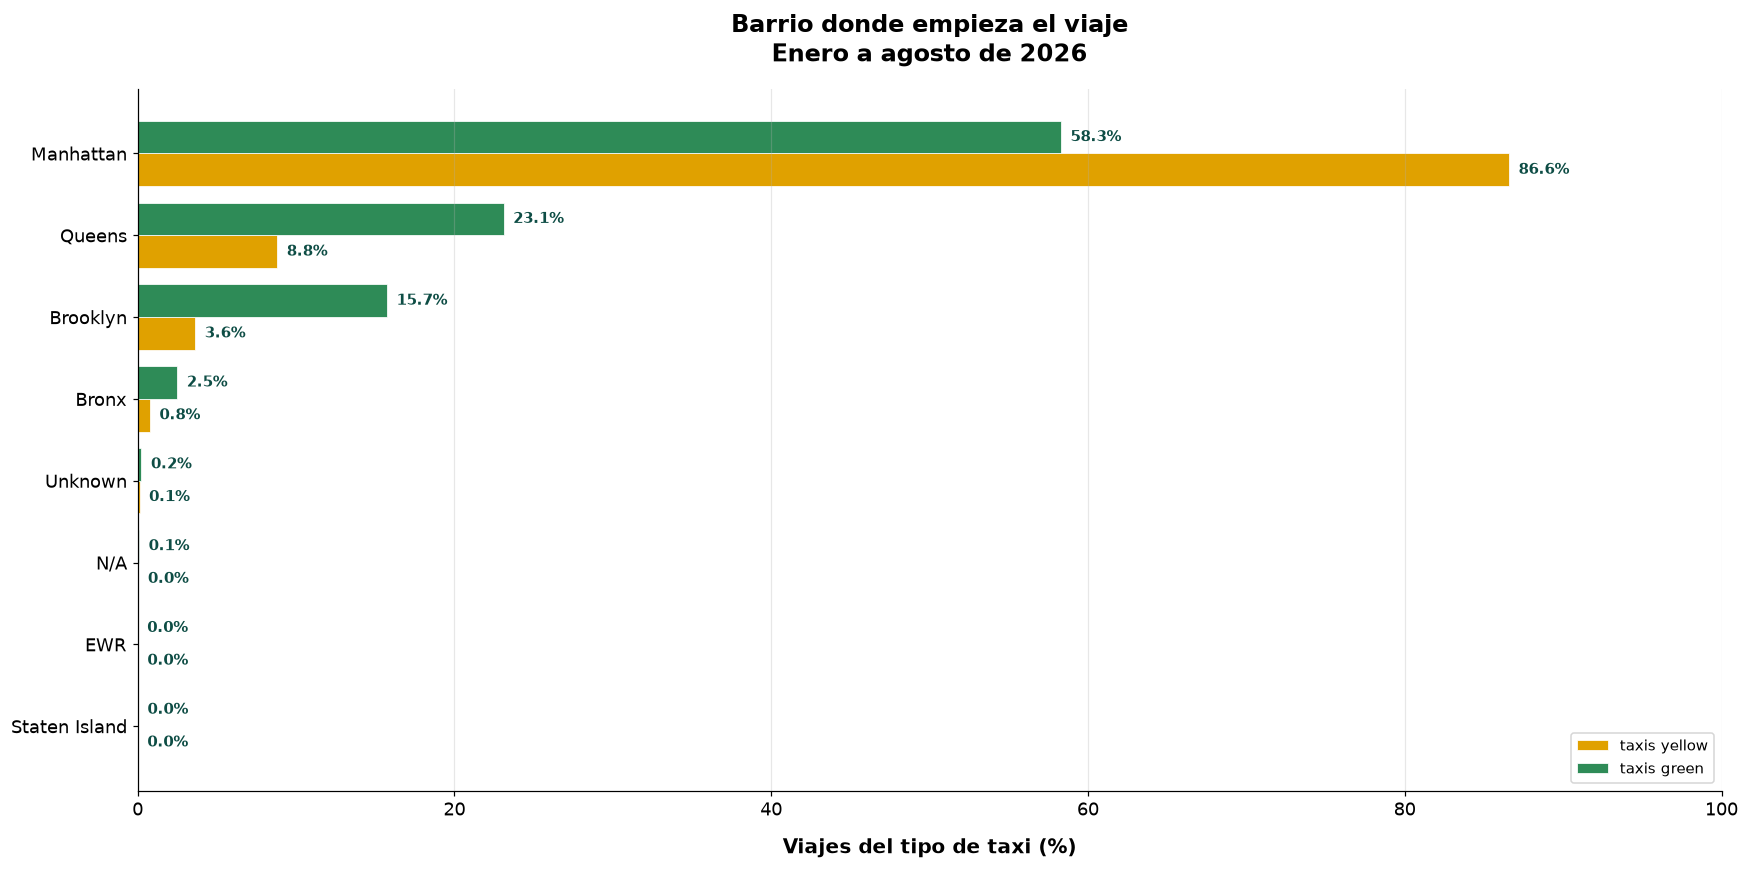

,tipo,barrio,viajes,pct_del_tipo
0,yellow,Manhattan,25578892,86.59
1,yellow,Queens,2604036,8.81
2,yellow,Brooklyn,1073842,3.64
3,yellow,Bronx,228545,0.77
4,yellow,Unknown,34830,0.12
5,yellow,N/A,14187,0.05
6,yellow,EWR,3963,0.01
7,yellow,Staten Island,2947,0.01
8,green,Manhattan,195874,58.30
9,green,Queens,77631,23.11


In [10]:
barrios = correr(con, "03_barrios.sql")
fig, ax = graficar_barrios(barrios)
plt.show()
barrios.round(2)

Los dos tipos de taxi atienden mercados distintos. El 86.6% de los viajes amarillos empieza en Manhattan y otro 8.8% en Queens, donde estan los dos aeropuertos. Los verdes estan mucho mas repartidos: 58.3% en Manhattan, 23.1% en Queens y 15.7% en Brooklyn, mas de cuatro veces la proporcion de amarillos que sale de Brooklyn (3.6%). Confirma la pista del perfil del cuaderno 02: los amarillos operan sobre todo dentro de la zona con recargo de congestion, y los verdes fuera de ella.

### 7.6 P4. Zonas con mas viajes

In [11]:
correr(con, "03_zonas_principales.sql").round(2)

-- 03_zonas_principales.sql
-- Objetivo: las ocho zonas donde mas viajes empiezan, por tipo de taxi
-- (pregunta 4).
-- Fuente: vista viajes_validos unida con la vista zonas por PULocationID.
with conteo as (
    select v.tipo, z.Zone as zona, z.Borough as barrio, count(*) as viajes
    from viajes_validos v
    left join zonas z on v.PULocationID = z.LocationID
    group by v.tipo, zona, barrio
)
select
    tipo,
    zona,
    barrio,
    viajes,
    100.0 * viajes / sum(viajes) over (partition by tipo) as pct_del_tipo
from conteo
qualify row_number() over (partition by tipo order by viajes desc) <= 8
order by tipo desc, viajes desc;



,tipo,zona,barrio,viajes,pct_del_tipo
0,yellow,Upper East Side South,Manhattan,1300930,4.40
1,yellow,Midtown Center,Manhattan,1216108,4.12
2,yellow,Upper East Side North,Manhattan,1164241,3.94
3,yellow,JFK Airport,Queens,1157943,3.92
4,yellow,Penn Station/Madison Sq West,Manhattan,898254,3.04
5,yellow,Midtown East,Manhattan,897276,3.04
6,yellow,Times Sq/Theatre District,Manhattan,846146,2.86
7,yellow,Lincoln Square East,Manhattan,843937,2.86
8,green,East Harlem North,Manhattan,88257,26.27
9,green,East Harlem South,Manhattan,43036,12.81


Ninguna zona concentra mas del 5% de los viajes amarillos. Las principales son el Upper East Side (sur 4.4% y norte 3.9%), Midtown Center (4.1%) y el aeropuerto JFK (3.9%, 1,157,943 viajes). En los verdes pasa lo contrario: East Harlem North y East Harlem South suman 39.1% de todos sus viajes, y el resto de su lista esta en el norte de Manhattan (Morningside Heights, Central Harlem), en Queens (Forest Hills, Elmhurst) o en Brooklyn (Downtown Brooklyn). El mapa coincide con la regla de la TLC para los taxis verdes, que solo pueden recoger pasajeros en la calle en el norte de Manhattan y en los otros barrios. La regla no viene en los datos, pero el resultado se ve en ellos.

### 7.7 P5. Forma de pago por mes

-- 03_pago_por_mes.sql
-- Objetivo: como pagan los pasajeros de cada tipo de taxi, mes por mes
-- (pregunta 5).
-- Fuente: vista viajes_validos. payment_type segun el diccionario de la TLC:
-- 0 Flex Fare (en verdes llega nulo), 1 tarjeta, 2 efectivo; 3 sin cargo,
-- 4 disputa, 5 desconocido y 6 anulado se agrupan en "otro".
select
    tipo,
    mes,
    case
        when payment_type = 1 then 'tarjeta'
        when payment_type = 2 then 'efectivo'
        when payment_type = 0 or payment_type is null then 'flex fare'
        else 'otro'
    end as pago,
    count(*) as viajes,
    100.0 * count(*) / sum(count(*)) over (partition by tipo, mes) as pct_del_mes
from viajes_validos
group by tipo, mes, pago
order by tipo desc, mes, pago;



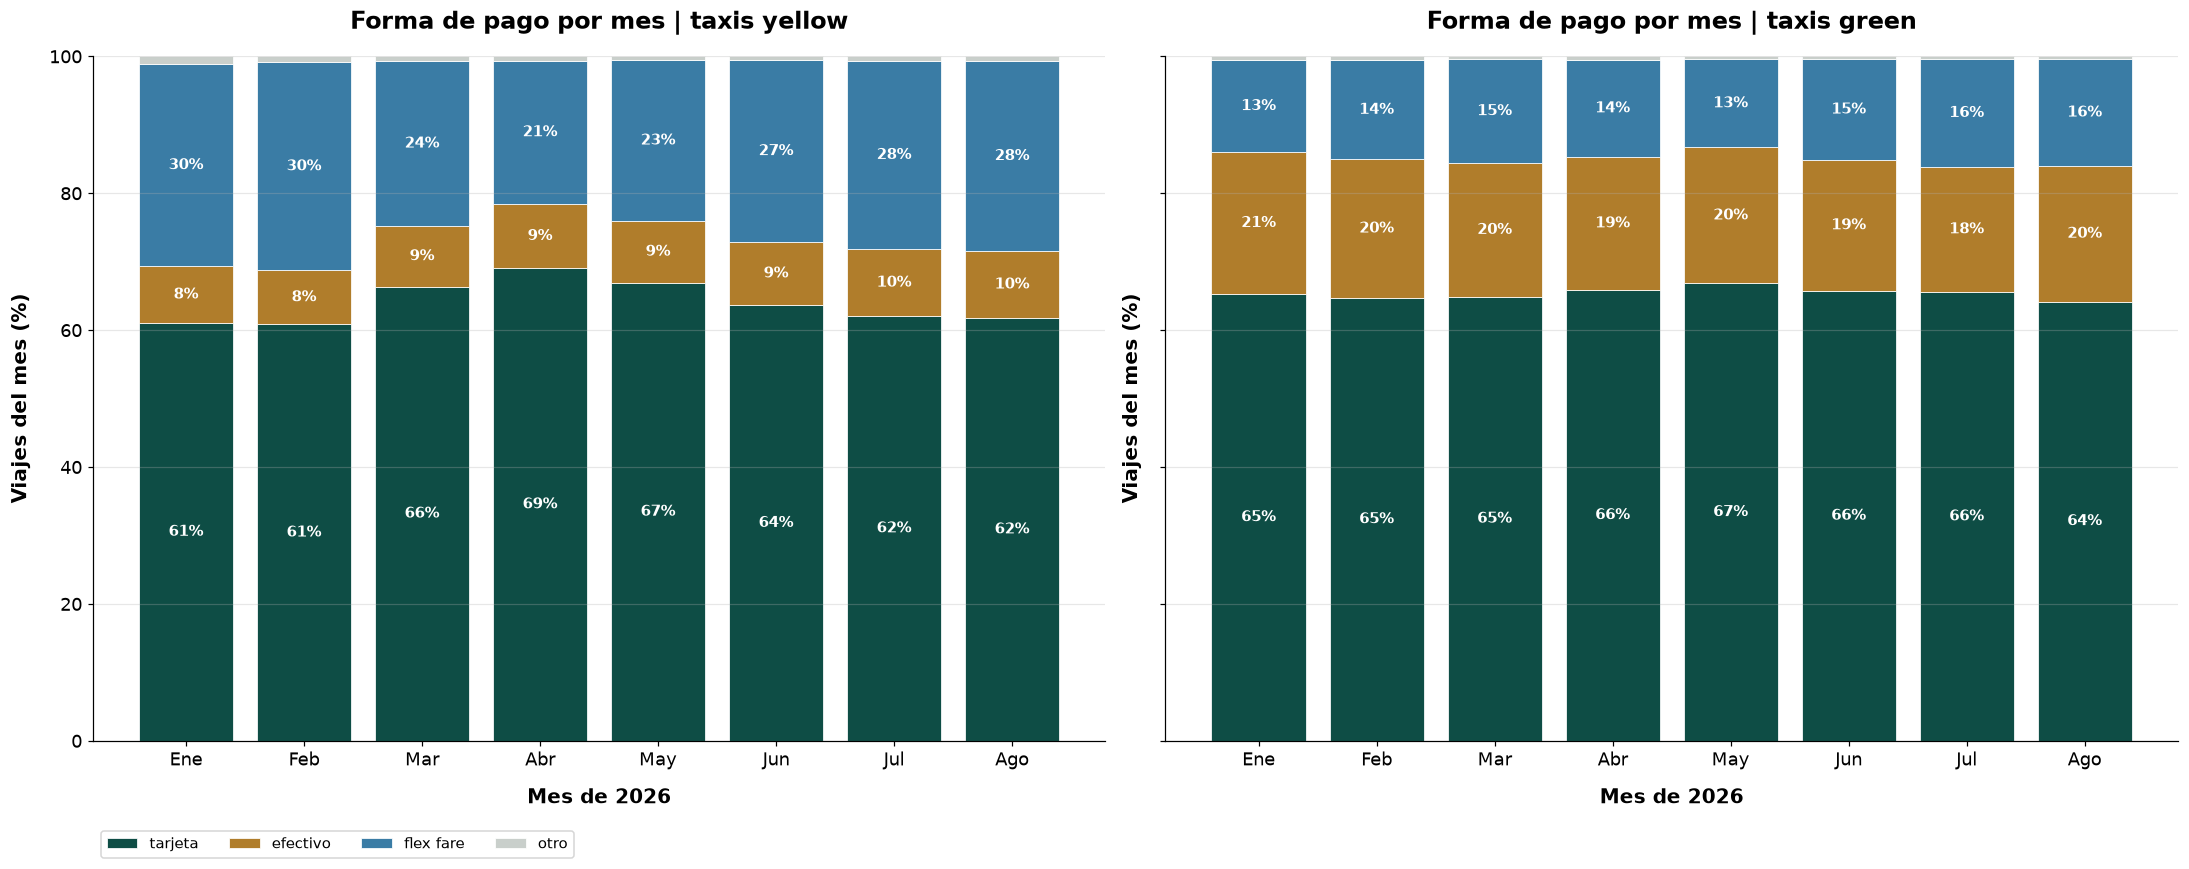

yellow                           green                        
pago tarjeta efectivo flex fare otro tarjeta efectivo flex fare otro
mes                                                                 
1       61.0      8.3      29.5  1.2    65.3     20.7      13.5  0.5
2       60.8      7.9      30.3  0.9    64.7     20.2      14.5  0.6
3       66.4      8.9      24.1  0.7    64.9     19.5      15.2  0.4
4       69.1      9.4      21.0  0.6    65.9     19.3      14.3  0.5
5       66.9      9.1      23.4  0.6    66.8     19.9      12.9  0.4
6       63.6      9.3      26.5  0.6    65.7     19.1      14.7  0.4
7       62.1      9.7      27.6  0.6    65.5     18.3      15.7  0.5
8       61.7      9.8      27.7  0.7    64.2     19.8      15.6  0.4

In [12]:
pago = correr(con, "03_pago_por_mes.sql")
fig, axes = graficar_pago(pago)
plt.show()
pd.concat({tipo: pago_ancho(pago, tipo) for tipo in TIPOS}, axis=1).round(1)

La tarjeta domina en los dos tipos (61% a 69% de los viajes amarillos cada mes, 64% a 67% de los verdes), pero el resto se reparte distinto. Los verdes pagan en efectivo cerca de una de cada cinco veces (18.3% a 20.7%), alrededor del doble que los amarillos (7.9% a 9.8%). Los amarillos tienen en cambio muchos mas viajes Flex Fare: entre 21.0% (abril) y 30.3% (febrero), contra 12.9% a 15.7% en verdes. En los amarillos esa participacion se mueve en espejo con la tarjeta: abril tiene el maximo de tarjeta (69.1%) y el minimo de Flex Fare (21.0%). El efectivo amarillo sube despacio, de 8.3% en enero a 9.8% en agosto.

### 7.8 P5. Propinas

In [13]:
correr(con, "03_propina.sql").round(2)

-- 03_propina.sql
-- Objetivo: que parte de los viajes deja propina y de cuanto, segun la forma
-- de pago (pregunta 5).
-- Fuente: vista viajes_validos. El diccionario de la TLC aclara que
-- tip_amount solo registra propinas con tarjeta; las de efectivo no quedan.
-- La propina como porcentaje de la tarifa se calcula solo con tarifa positiva.
select
    tipo,
    case
        when payment_type = 1 then 'tarjeta'
        when payment_type = 2 then 'efectivo'
        when payment_type = 0 or payment_type is null then 'flex fare'
        else 'otro'
    end as pago,
    count(*) as viajes,
    100.0 * count_if(tip_amount > 0) / count(*) as pct_con_propina,
    median(tip_amount) filter (where tip_amount > 0) as propina_mediana,
    median(100 * tip_amount / fare_amount) filter (where tip_amount > 0 and fare_amount > 0)
        as propina_pct_tarifa_mediana
from viajes_validos
group by tipo, pago
order by tipo desc, viajes desc;



,tipo,pago,viajes,pct_con_propina,propina_mediana,propina_pct_tarifa_mediana
0,yellow,tarjeta,18937381,91.10,3.51,27.27
1,yellow,flex fare,7716459,8.14,3.97,21.46
2,yellow,efectivo,2668361,0.01,3.60,27.42
3,yellow,otro,219041,0.03,3.70,28.91
4,green,tarjeta,219766,90.45,3.34,24.17
5,green,efectivo,65859,0.00,NaN,NaN
6,green,flex fare,48773,16.14,3.88,20.77
7,green,otro,1594,1.07,0.90,30.00


La propina solo se puede estudiar en los pagos con tarjeta, y los datos lo confirman: de 2,668,361 viajes amarillos pagados en efectivo, solo 182 traen propina (0.01%), como advierte el diccionario. Con tarjeta, 91.1% de los viajes amarillos y 90.4% de los verdes dejan propina, con una mediana de 3.51 y 3.34 dolares, que equivale a 27.3% y 24.2% de la tarifa. En Flex Fare solo 8.1% de los amarillos registra propina. La consecuencia practica: un promedio de propina sobre todos los viajes la subestima mucho, porque el efectivo y gran parte de Flex Fare entran con cero aunque el pasajero si haya dejado propina.

### 7.9 P6. Distribucion del total

-- 03_total_histograma.sql
-- Objetivo: distribucion del total pagado por viaje, en intervalos de 2
-- dolares hasta 150 (pregunta 6). Lo que pasa de 150 se junta en el ultimo
-- intervalo para que la cola no aplaste el resto de la grafica.
-- Fuente: vista viajes_validos.
select
    tipo,
    least(floor(total_amount / 2) * 2, 150) as desde_dolares,
    count(*) as viajes,
    100.0 * count(*) / sum(count(*)) over (partition by tipo) as pct_del_tipo
from viajes_validos
group by tipo, desde_dolares
order by tipo desc, desde_dolares;



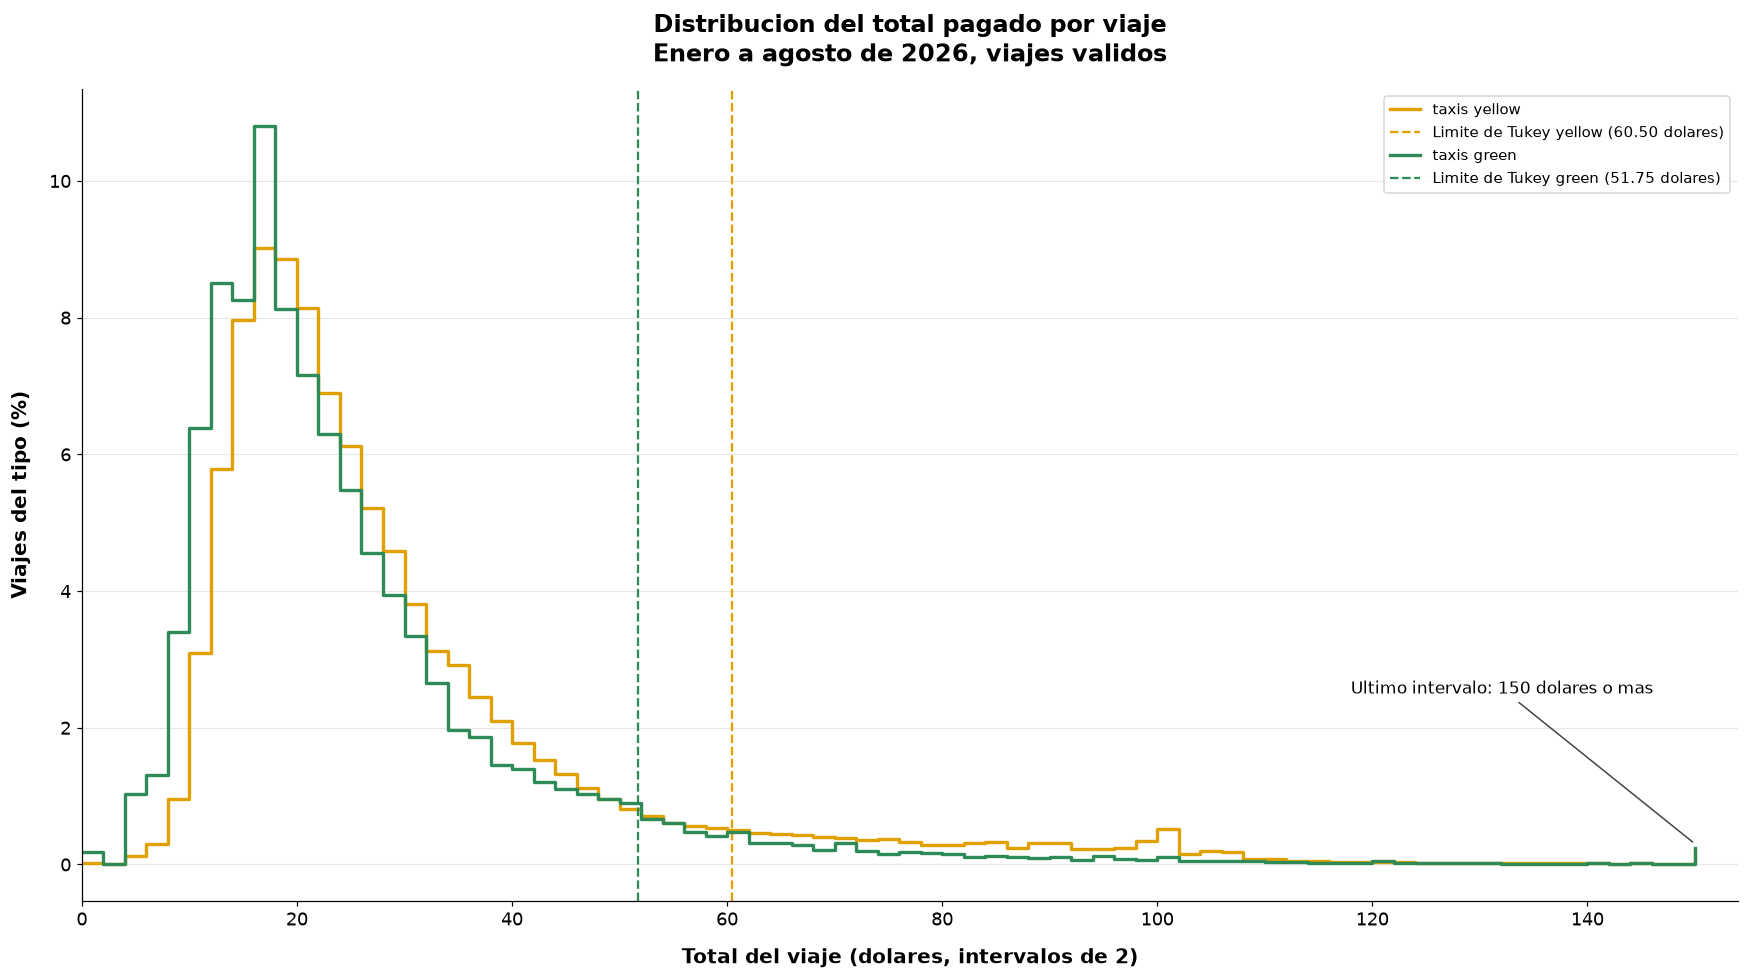

,tipo,desde_dolares,viajes,pct_del_tipo
84,green,16.0,36308,10.81
8,yellow,16.0,2663078,9.01
9,yellow,18.0,2618309,8.86
82,green,12.0,28588,8.51
83,green,14.0,27729,8.25
10,yellow,20.0,2406763,8.15


-- 03_pico_100_dolares.sql
-- Objetivo: que viajes forman el pequeno pico de la distribucion del total
-- entre 100 y 102 dolares en los amarillos (pregunta 6).
-- Fuente: vista viajes_validos. RatecodeID 2 es la tarifa fija de JFK.
select
    RatecodeID,
    count(*) as viajes,
    100.0 * count(*) / sum(count(*)) over () as pct_del_pico,
    median(fare_amount) as tarifa_mediana,
    median(tolls_amount) as peajes_mediana,
    median(tip_amount) as propina_mediana,
    median(total_amount) as total_mediano
from viajes_validos
where tipo = 'yellow'
  and total_amount >= 100
  and total_amount < 102
group by RatecodeID
order by viajes desc;



,RatecodeID,viajes,pct_del_pico,tarifa_mediana,peajes_mediana,propina_mediana,total_mediano
0,2,127857,83.27,70.00,7.46,16.44,100.65
1,1,11192,7.29,72.30,7.46,16.58,100.94
2,5,7969,5.19,85.00,0.00,12.00,100.80
3,<NA>,4178,2.72,81.05,7.46,0.00,101.00
4,3,1414,0.92,76.55,7.46,10.00,100.94
5,4,867,0.56,84.90,0.00,5.00,100.86
6,99,70,0.05,99.50,0.00,0.00,100.80


In [14]:
histograma = correr(con, "03_total_histograma.sql")
atipicos = correr(con, "03_atipicos.sql", mostrar=False)
fig, ax = graficar_total(histograma, atipicos)
plt.show()
display(histograma.sort_values("pct_del_tipo", ascending=False).groupby("tipo").head(3).round(2))
correr(con, "03_pico_100_dolares.sql").round(2)

El total por viaje tiene una distribucion asimetrica con una cola larga a la derecha. El intervalo mas comun es de 16 a 18 dolares en los dos tipos (9.0% de los amarillos y 10.8% de los verdes), y los verdes se concentran en montos algo mas bajos, de 12 a 18 dolares. La cola tiene una marca visible: un pequeno pico de amarillos entre 100 y 102 dolares. El 83.3% de esos viajes tiene codigo de tarifa 2, la tarifa fija de JFK, y su suma es directa: 70 dolares de tarifa, 7.46 de peajes y una propina mediana de 16.44 dan 100.65. Esa cola no es ruido, son viajes al aeropuerto con precio fijo.

### 7.10 P6. Componentes del total

-- 03_composicion.sql
-- Objetivo: de que se compone el total pagado en promedio, por tipo de taxi
-- (pregunta 6).
-- Fuente: vista viajes_validos, solo viajes cuyo total coincide con la suma de
-- sus componentes (diferencia de un centavo o menos). En los demas el desglose
-- no es confiable (ver 03_total_no_cuadra.sql).
with v as (
    select
        *,
        fare_amount + extra + mta_tax + tip_amount + tolls_amount + improvement_surcharge
            + coalesce(congestion_surcharge, 0) + coalesce(Airport_fee, 0)
            + cbd_congestion_fee + coalesce(ehail_fee, 0) as suma_componentes
    from viajes_validos
)
select
    tipo,
    count(*) as viajes,
    avg(fare_amount) as tarifa,
    avg(tip_amount) as propina,
    avg(coalesce(congestion_surcharge, 0)) as recargo_congestion,
    avg(cbd_congestion_fee) as cargo_zona_central,
    avg(coalesce(Airport_fee, 0)) as cargo_aeropuerto,
    avg(tolls_amount) as peajes,
    avg(extra) as extras,
    avg(mta_tax + improvement_surcha

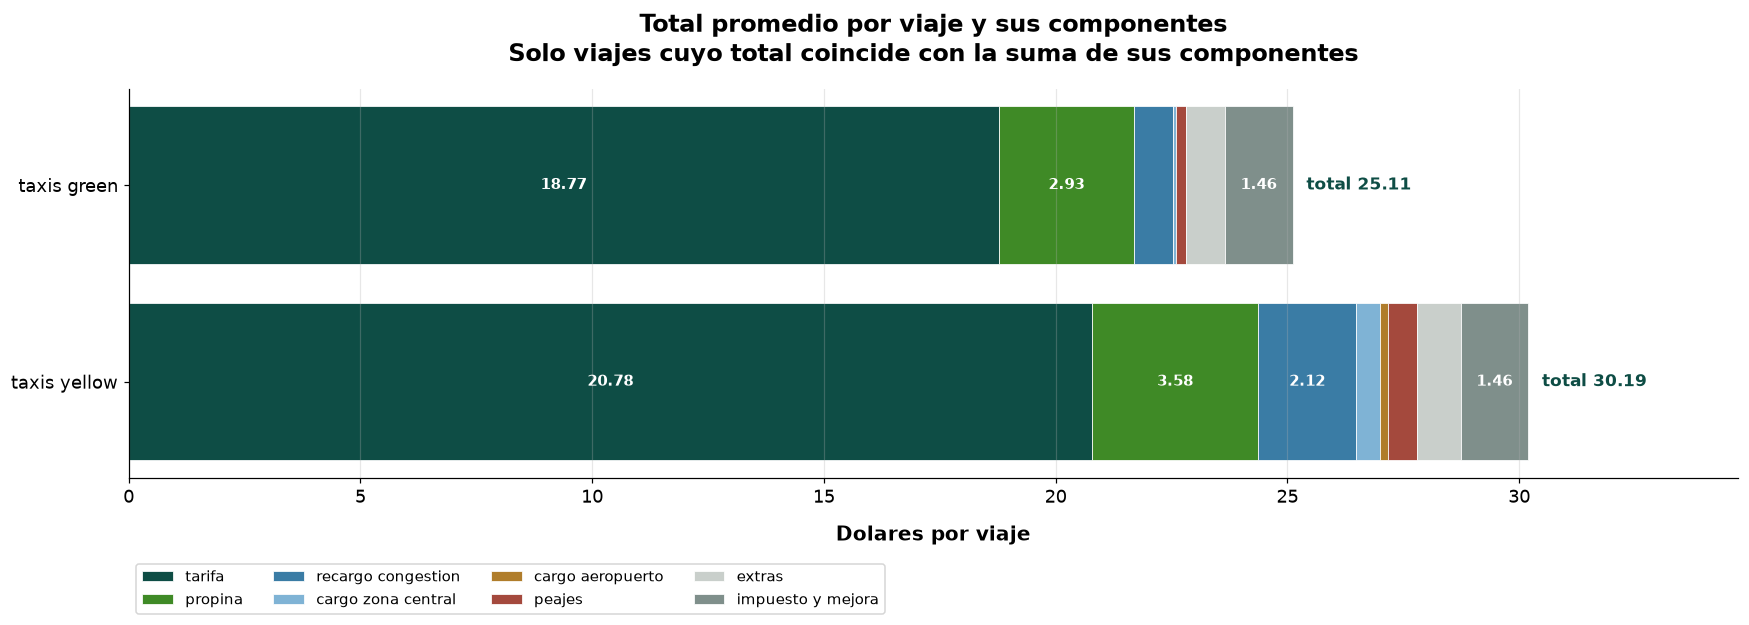

,tipo,viajes,tarifa,propina,recargo_congestion,cargo_zona_central,cargo_aeropuerto,peajes,extras,impuesto_y_mejora,total
0,yellow,18645977,20.78,3.58,2.12,0.51,0.17,0.62,0.94,1.46,30.19
1,green,269024,18.77,2.93,0.84,0.06,0.00,0.22,0.83,1.46,25.11


In [15]:
composicion = correr(con, "03_composicion.sql")
fig, ax = graficar_composicion(composicion)
plt.show()
composicion.round(2)

En los viajes cuyo desglose cuadra (18.6 millones de amarillos, 63% de los validos, y 269,024 verdes) el total promedio es de 30.19 dolares en amarillos y 25.11 en verdes. La tarifa del taximetro es el 69% del total amarillo (20.78 dolares) y el 75% del verde (18.77). La diferencia esta en los cargos por entrar a la zona central: recargo de congestion y cargo de la zona central suman 2.63 dolares por viaje amarillo, 8.7% del total, contra 0.90 en verdes. La propina promedio es de 3.58 dolares en amarillos y 2.93 en verdes. Una advertencia: los viajes que cuadran son sobre todo del proveedor 2 y no incluyen Flex Fare (paso 7.12), asi que este desglose describe a ese grupo y no a todos los viajes.

### 7.11 P7. Reglas entre columnas

In [16]:
inconsistencias = correr(con, "03_inconsistencias.sql")
inconsistencias

-- 03_inconsistencias.sql
-- Objetivo: registros que contradicen una regla entre columnas (pregunta 7).
-- Fuente: vista viajes_validos. Reglas:
--   total distinto de la suma de componentes (mas de un centavo);
--   cargo de aeropuerto sin salir de JFK (zona 132) ni LaGuardia (138), que
--   segun el diccionario es el unico caso en que se cobra;
--   velocidad promedio mayor a 80 mph en un viaje medible;
--   propina registrada en un viaje pagado en efectivo, que el diccionario
--   dice que no se registra.
select
    tipo,
    count(*) as viajes,
    count_if(abs(total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount
        + improvement_surcharge + coalesce(congestion_surcharge, 0) + coalesce(Airport_fee, 0)
        + cbd_congestion_fee + coalesce(ehail_fee, 0))) > 0.01) as total_no_cuadra,
    count_if(Airport_fee > 0) as con_cargo_aeropuerto,
    count_if(Airport_fee > 0 and PULocationID not in (132, 138)) as cargo_aeropuerto_fuera,
    count_if(medible) as med

,tipo,viajes,total_no_cuadra,con_cargo_aeropuerto,cargo_aeropuerto_fuera,medibles,mas_de_80_mph,en_efectivo,efectivo_con_propina
0,yellow,29541242,10895265.0,1898118.0,56287.0,28242681.0,7210.0,2668361.0,182.0
1,green,335992,66968.0,NaN,0.0,324158.0,1087.0,65859.0,0.0


Cuatro reglas que cruzan columnas, y solo una es grande:

- **El total no coincide con la suma de sus componentes** en 10,895,265 viajes amarillos (36.9%) y 66,968 verdes (19.9%). Es el hallazgo de calidad mas importante de este cuaderno; el paso 7.12 muestra de donde sale.
- **Cargo de aeropuerto fuera del aeropuerto:** 56,287 viajes amarillos lo cobran sin salir de JFK ni de LaGuardia, el 3.0% de los 1,898,118 que lo cobran. Puede ser una salida desde una zona vecina mal asignada; los datos no permiten saberlo.
- **Velocidades imposibles:** 7,210 viajes amarillos medibles (0.026%) y 1,087 verdes (0.34%) promedian mas de 80 mph, algo que no ocurre dentro de la ciudad. La distancia o el tiempo estan mal registrados.
- **Propina en efectivo:** 182 viajes la traen, cuando el diccionario dice que no se registra. Es marginal.

### 7.12 P7. De donde vienen los totales que no cuadran

In [17]:
correr(con, "03_total_no_cuadra.sql").round(2)

-- 03_total_no_cuadra.sql
-- Objetivo: en cuantos viajes el total no es la suma de sus componentes y de
-- quien vienen (pregunta 7). Componentes: tarifa, extras, impuesto MTA,
-- propina, peajes, recargo de mejora, recargo de congestion, cargo de
-- aeropuerto, cargo de la zona central y ehail_fee.
-- Fuente: vista viajes_validos.
with v as (
    select
        tipo,
        VendorID,
        payment_type = 0 or payment_type is null as flex_fare,
        total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount
            + improvement_surcharge + coalesce(congestion_surcharge, 0)
            + coalesce(Airport_fee, 0) + cbd_congestion_fee + coalesce(ehail_fee, 0)) as diferencia
    from viajes_validos
)
select
    tipo,
    VendorID,
    flex_fare,
    count(*) as viajes,
    count_if(abs(diferencia) > 0.01) as no_cuadra,
    100.0 * count_if(abs(diferencia) > 0.01) / count(*) as pct_no_cuadra,
    median(diferencia) filter (where abs(diferencia) > 0.01) as diferenci

,tipo,VendorID,flex_fare,viajes,no_cuadra,pct_no_cuadra,diferencia_mediana
0,yellow,1,False,4571690,3811835.0,83.38,-3.25
1,yellow,1,True,895381,881566.0,98.46,4.07
2,yellow,2,False,16885973,22169.0,0.13,2.50
3,yellow,2,True,6761688,5963028.0,88.19,2.50
4,yellow,6,True,59390,59389.0,100.00,24.74
5,yellow,7,False,367120,157278.0,42.84,1.00
6,green,1,False,28168,27333.0,97.04,-1.00
7,green,1,True,528,339.0,64.20,2.75
8,green,2,False,259051,106.0,0.04,2.50
9,green,2,True,13398,4343.0,32.42,2.75


El total que no cuadra tiene responsables claros. Los viajes normales del proveedor 2 (Curb) cuadran casi siempre: solo falla el 0.13% de 16.9 millones en amarillos y el 0.04% en verdes. Los problemas se concentran en tres grupos:

- **Proveedor 1 (Creative Mobile):** no cuadra el 83.4% de sus viajes amarillos normales, y su total es menor que la suma por una mediana de exactamente 3.25 dolares, lo que valen juntos el recargo de congestion (2.50) y el cargo de la zona central (0.75). Estos cargos se cuentan dos veces en el desglose o no entran al total; con los datos no se puede saber cual de las dos.
- **Flex Fare:** no cuadra entre el 88% y el 98% de esos viajes amarillos y el total es mayor que la suma. En el proveedor 2 la diferencia mediana es justo 2.50 dolares, el recargo de congestion, que en esas filas viene nulo: el cargo se cobra pero no se reporta en su columna.
- **Proveedor 6 (Myle):** no cuadra nunca, y su total supera la suma por 22 a 25 dolares, asi que su `fare_amount` no es la tarifa completa.

Para el analisis: `total_amount` se usa tal como viene para hablar de lo que se paga, y el desglose solo en los viajes donde cuadra, como hizo el paso 7.10.

### 7.13 P7. Atipicos segun Tukey

In [18]:
print(consultas.leer_sql("03_atipicos.sql"))
display(atipicos.round(2))
correr(con, "03_atipicos_por_tarifa.sql").round(2)

-- 03_atipicos.sql
-- Objetivo: cuantos viajes quedan por encima del limite de Tukey (tercer
-- cuartil mas 1.5 veces el rango intercuartil) en total, distancia y
-- duracion, por tipo de taxi (pregunta 7).
-- Fuente: vista viajes_validos; distancia y duracion solo de viajes medibles.
with largo as (
    select tipo, 'total_dolares' as variable, total_amount as valor from viajes_validos
    union all
    select tipo, 'distancia_millas', trip_distance from viajes_validos where medible
    union all
    select tipo, 'duracion_min', duracion_min from viajes_validos where medible
),
limites as (
    select
        tipo,
        variable,
        quantile_cont(valor, 0.25) as q1,
        quantile_cont(valor, 0.75) as q3
    from largo
    group by tipo, variable
)
select
    l.variable,
    l.tipo,
    any_value(q1) as q1,
    any_value(q3) as q3,
    any_value(q3 + 1.5 * (q3 - q1)) as limite_superior,
    count(*) as viajes,
    count_if(l.valor > q3 + 1.5 * (q3 - q1)) as sobre_el_limite,


,variable,tipo,q1,q3,limite_superior,viajes,sobre_el_limite,pct_sobre_el_limite
0,distancia_millas,yellow,1.10,3.95,8.23,28242681,3085081.0,10.92
1,distancia_millas,green,1.33,3.78,7.46,324158,32997.0,10.18
2,duracion_min,yellow,8.62,22.27,42.74,28242681,1534095.0,5.43
3,duracion_min,green,8.68,20.73,38.81,324158,23025.0,7.10
4,total_dolares,yellow,17.52,34.71,60.50,29541242,2510369.0,8.50
5,total_dolares,green,15.00,29.70,51.75,335992,22753.0,6.77


-- 03_atipicos_por_tarifa.sql
-- Objetivo: con que codigo de tarifa vienen los viajes cuyo total pasa el
-- limite de Tukey, para saber si son errores o viajes de otra clase
-- (pregunta 7).
-- Fuente: vista viajes_validos. RatecodeID segun el diccionario de la TLC:
-- 1 estandar, 2 JFK, 3 Newark, 4 Nassau o Westchester, 5 negociada,
-- 6 grupal, 99 desconocido; nulo en los viajes Flex Fare.
with limites as (
    select
        tipo,
        quantile_cont(total_amount, 0.75)
            + 1.5 * (quantile_cont(total_amount, 0.75) - quantile_cont(total_amount, 0.25)) as limite
    from viajes_validos
    group by tipo
)
select
    v.tipo,
    case v.RatecodeID
        when 1 then '1 estandar'
        when 2 then '2 JFK'
        when 3 then '3 Newark'
        when 4 then '4 Nassau o Westchester'
        when 5 then '5 negociada'
        when 6 then '6 grupal'
        when 99 then '99 desconocido'
        else 'sin codigo (flex fare)'
    end as codigo_tarifa,
    count(*) as viajes,
    1

,tipo,codigo_tarifa,viajes,pct_de_los_atipicos,tarifa_mediana,total_mediano
0,yellow,1 estandar,1069129,42.59,49.20,74.11
1,yellow,2 JFK,683227,27.22,70.00,96.75
2,yellow,sin codigo (flex fare),412699,16.44,60.02,70.77
3,yellow,5 negociada,183570,7.31,85.00,101.00
4,yellow,3 Newark,68652,2.73,85.30,115.75
5,yellow,4 Nassau o Westchester,52955,2.11,115.70,143.57
6,yellow,99 desconocido,40137,1.60,61.50,66.46
7,green,1 estandar,9941,43.69,47.10,61.50
8,green,5 negociada,6628,29.13,70.00,81.00
9,green,sin codigo (flex fare),4928,21.66,3.00,60.59


La regla de Tukey marca muchos viajes: en amarillos, 8.5% por total (mas de 60.50 dolares), 10.9% por distancia (mas de 8.2 millas) y 5.4% por duracion (mas de 42.7 minutos); en verdes, 6.8%, 10.2% y 7.1%. Con colas tan largas, esos limites no separan errores de viajes reales, y la segunda tabla lo muestra para el total. De los 2.5 millones de amarillos sobre el limite, 27.2% son tarifa fija de JFK (mediana de 70 dolares), 7.3% tarifa negociada, 2.7% Newark y 2.1% Nassau o Westchester: al menos 39% son viajes con una tarifa especial que se espera alta. Otro 42.6% tiene tarifa estandar con una tarifa mediana de 49.20 dolares, viajes largos normales. Solo grupos pequenos, como el 1.6% con codigo 99, merecen sospecha. En este conjunto los atipicos estadisticos no son el problema de calidad: los problemas reales son los del cuaderno 02 y las reglas entre columnas, y esos Tukey no los detecta.

### 7.14 Bitacora de consultas (4.3)

In [19]:
bitacora = pd.DataFrame(BITACORA)
print(f"Consultas ejecutadas: {len(bitacora)} | tiempo total: {bitacora['segundos'].sum():.1f} s")
bitacora

Consultas ejecutadas: 15 | tiempo total: 20.2 s


,consulta,filas_resultado,segundos
0,03_viajes_por_mes.sql,16,0.452
1,03_hora_dia.sql,336,0.555
2,03_caracteristicas.sql,6,5.663
3,03_velocidad_por_hora.sql,48,1.047
4,03_barrios.sql,16,0.568
5,03_zonas_principales.sql,16,0.498
6,03_pago_por_mes.sql,64,0.405
7,03_propina.sql,8,1.236
8,03_total_histograma.sql,152,0.408
9,03_atipicos.sql,6,4.602


El cuaderno corrio 15 consultas en unos 20 segundos sobre 30 millones de viajes, siempre a traves de la vista `viajes_validos`, es decir, leyendo los Parquet en cada consulta. La mas lenta es la de percentiles exactos de distancia, duracion y velocidad (entre 5 y 9 s segun la corrida), porque un percentil exacto necesita ordenar los 28 millones de valores de cada variable; la de limites de Tukey le sigue por la misma razon. Las demas tardan alrededor de un segundo o menos. Todas estan documentadas en `docs/consultas.md` con su objetivo, fuente, resultado y decision.

## 8. Conclusiones

**Respuestas a las preguntas (4.4).**

- **P1, meses.** Los dos tipos crecen de enero a mayo y junio y caen en julio y agosto. Los amarillos bajan de 131,482 viajes por dia en mayo a 107,167 en agosto (18.5% menos); los verdes vuelven al nivel de enero.
- **P2, horas y dias.** Los amarillos tienen su maximo el jueves a las 18:00 (10,000 viajes por hora), noches de fin de semana fuertes y el mismo volumen en fin de semana que en dia habil (1.0% menos). Los verdes son un servicio de dias habiles: 24% menos viajes en fin de semana.
- **P3, caracteristicas.** El viaje tipico es de unas 2 millas y 14 minutos, a 9 o 10 mph. De la madrugada a la tarde la velocidad cae a la mitad y la duracion casi no cambia.
- **P4, geografia.** 86.6% de los amarillos sale de Manhattan; los verdes se reparten entre Manhattan, Queens y Brooklyn, y 39.1% sale de East Harlem.
- **P5, pago.** La tarjeta cubre 61% a 69% de los viajes; los verdes pagan en efectivo alrededor del doble que los amarillos; con tarjeta, 91% deja propina, con una mediana de 27% de la tarifa en amarillos.
- **P6, montos.** El total mas comun es de 16 a 18 dolares, con una cola de viajes al aeropuerto que forma un pico en 100 dolares por la tarifa fija de JFK. La tarifa del taximetro es 69% del total amarillo y los cargos de la zona central, 8.7%.
- **P7, atipicos e inconsistencias.** El total no es la suma de sus partes en 36.9% de los amarillos, por como reportan el proveedor 1, el proveedor 6 y los viajes Flex Fare. Los atipicos de Tukey son sobre todo viajes legitimos con tarifa especial.

**Hallazgos relevantes (4.5).**

1. **Amarillos y verdes son dos mercados distintos, no dos versiones del mismo.** Los amarillos son un servicio de Manhattan (86.6% de sus salidas), sin diferencia entre dias habiles y fin de semana, con mucho Flex Fare. Los verdes salen en 39% de dos zonas de East Harlem, trabajan sobre todo en dias habiles y cobran en efectivo una de cada cinco veces. Comparar sus promedios directamente mezcla geografias distintas.
2. **Un viaje en taxi dura lo mismo a cualquier hora; lo que cambia es cuanto se avanza.** La velocidad de los amarillos va de 16.0 a 7.9 mph entre las 5:00 y las 15:00, pero la duracion mediana se queda entre 13.6 y 15.3 minutos y la distancia baja de 3.71 a 1.73 millas.
3. **El verano golpea a los amarillos y casi no a los verdes.** De mayo a agosto los amarillos pierden 18.5% de sus viajes diarios; los verdes quedan cerca de su nivel de enero.
4. **El total pagado no siempre es la suma de sus partes.** En 36.9% de los amarillos no coincide, y casi todo se explica por quien reporta: el proveedor 2 cuadra en 99.9% de sus viajes normales. Cualquier analisis de cargos o tarifas tiene que filtrar por proveedor o usar el total tal como viene.
5. **La propina solo existe en los datos cuando se paga con tarjeta.** Con tarjeta, 91% de los viajes deja propina; en efectivo los datos dicen 0.01% porque no se registra. Un promedio general la subestima.

**Limitaciones.** Son ocho meses de un solo anio, sin datos de clima, eventos ni cambios de tarifa, asi que las explicaciones de causa (verano, trayectos cortos en horas lentas) quedan como hipotesis. La velocidad es el promedio de todo el viaje, no la del trafico en un punto. El barrio es el de la zona de salida.

**Para el ejercicio 5 (equipo).** Las consultas leen `viajes_validos`, que toma cualquier anio que haya en `data/raw`, pero `03_viajes_por_mes.sql` y `03_pago_por_mes.sql` agrupan por `mes` sin `anio` porque aqui solo hay 2026: al agregar 2024 habra que sumar `anio` a su agrupacion. Las demas consultas agregan sobre todo el periodo y funcionan igual con mas anios.